# 线性回归 - 梯度下降法

In [38]:
import numpy as np
from astropy.io.fits import append

In [39]:
# 1. 定义数据
# 自变量，每周学习时长
X = [[5], [8], [10], [12], [15], [3], [7], [9], [14], [6]]
# 因变量，数学考试成绩
y = [55, 65, 70, 75, 85, 50, 60, 72, 80, 58]

In [40]:
# 转成ndarray
X = np.array(X)
y = np.array(y).reshape(-1, 1) # 将y转换为二维数组 -1: 自动计算行数，1: 列数为1
# X增加一列1
n = X.shape[0]
X = np.hstack([np.ones((n, 1)), X]) # np.hstack() 将两个数组按水平方向拼接，np.ones((n, 1)) 生成一个n行1列的全1数组，表示截距项。

print(X)
print(y)

[[ 1.  5.]
 [ 1.  8.]
 [ 1. 10.]
 [ 1. 12.]
 [ 1. 15.]
 [ 1.  3.]
 [ 1.  7.]
 [ 1.  9.]
 [ 1. 14.]
 [ 1.  6.]]
[[55]
 [65]
 [70]
 [75]
 [85]
 [50]
 [60]
 [72]
 [80]
 [58]]


In [41]:
# 2. 定义损失函数和计算梯度的函数
# 传入beta为(2,1)的列向量
def J(beta):
    return np.sum((X @ beta - y) ** 2) / n # 损失函数J(beta) = (1/n) * Σ(y_i - (β0 + β1*x_i))^2，其中X @ beta表示矩阵乘法，n为样本数量。

def g(beta):
    return X.T @ (X @ beta - y) / n * 2 # 梯度g(beta) = (2/n) * X^T * (X*beta - y)，其中X.T表示X的转置矩阵。

In [42]:
# 3. 参数和超参数初始化
alpha = 0.01 # 超参数：学习率
iter = 10000 # 超参数：迭代次数
beta = np.array([[1], [1]]) # 参数初始化，beta为(2,1)的列向量，表示截距和斜率的初始值。

beta0 = []
beta1 = []

In [43]:
# 4. 循环迭代，梯度下降更新参数
for i in range(iter):
    beta0.append(beta[0, 0])
    beta1.append(beta[1, 0])
    # 计算梯度
    grad = g(beta)
    # 更新参数
    beta = beta - alpha * grad
    # 没迭代10次打印当前的参数值和损失值、梯度值
    if i % 10 == 0:
        print(f"iter: {i}, beta: {beta}, loss: {J(beta)}, grad: {grad}")

iter: 0, beta: [[ 2.142]
 [11.676]], loss: 2589.9686919999995, grad: [[ -114.2]
 [-1067.6]]
iter: 10, beta: [[2.9362414 ]
 [7.89167599]], loss: 386.20314712944514, grad: [[ -38.31966762]
 [-280.32353783]]
iter: 20, beta: [[3.95715236]
 [6.81731475]], loss: 221.82345385108283, grad: [[-18.10147421]
 [-73.04467444]]
iter: 30, beta: [[5.01435079]
 [6.45877238]], loss: 199.50216243097955, grad: [[-12.54680843]
 [-18.48720355]]
iter: 40, beta: [[6.05838064]
 [6.29089623]], loss: 187.6511170362875, grad: [[-10.85992464]
 [ -4.14292285]]
iter: 50, beta: [[7.07687436]
 [6.17534289]], loss: 177.11141951402635, grad: [[-10.19794957]
 [ -0.38675689]]
iter: 60, beta: [[8.06721149]
 [6.07562344]], loss: 167.21478003264423, grad: [[-9.81212582]
 [ 0.58200232]]
iter: 70, beta: [[9.02931976]
 [5.98207054]], loss: 157.8834928384659, grad: [[-9.50511343]
 [ 0.81738058]]
iter: 80, beta: [[9.9637801 ]
 [5.89208104]], loss: 149.08258250307713, grad: [[-9.22477411]
 [ 0.86021678]]
iter: 90, beta: [[10.87132

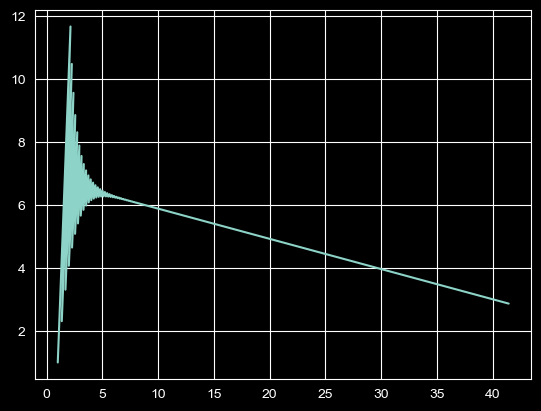

In [44]:
import matplotlib.pyplot as plt
plt.plot(beta0, beta1)
plt.show()